# Carregamento dos Dados
(Ana Silva)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, learning_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/anansilva/german-processed/german_processed.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/anansilva/german-processed/german_processed.csv")

In [3]:
df.head(15)

,Creditability,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,...,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,No_of_dependents,Telephone,Foreign_Worker,Credit_per_Month,Credit_Age_Ratio
0,1,1,-0.240857,4,2,-0.787657,1,2,4,2,...,-1.281573,3,1,1,3,1,1,1,-0.713147,-0.543155
1,1,1,-0.987573,4,0,-0.167384,1,3,2,3,...,0.040363,3,1,2,3,2,1,1,0.934161,-0.238406
2,1,2,-0.738668,2,9,-0.861381,2,4,2,2,...,-1.105315,3,1,1,2,1,1,1,-0.636195,-0.689919
3,1,1,-0.738668,4,0,-0.407341,1,3,3,3,...,0.304750,3,1,2,2,2,1,2,0.059628,-0.494282
4,1,1,-0.738668,4,0,-0.389974,1,3,4,3,...,0.216621,1,2,2,2,1,1,2,0.086245,-0.464448
5,1,1,-0.904604,4,0,-0.365163,1,2,1,3,...,1.097912,3,1,2,2,2,1,2,0.367725,-0.578948
6,1,1,-1.070541,4,0,0.044926,1,4,1,3,...,0.304750,3,2,2,2,1,1,2,1.675613,-0.135592
7,1,1,-1.236478,4,0,-0.677071,1,2,2,3,...,0.392879,3,2,1,2,2,1,2,0.385541,-0.717768
8,1,4,-0.240857,4,3,-0.770289,1,1,4,2,...,2.596106,3,2,2,1,1,1,1,-0.695403,-0.905596
9,1,2,0.256953,2,3,0.172525,3,1,1,2,...,-1.105315,3,1,1,1,1,1,1,-0.072366,0.700489


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Creditability                      1000 non-null   int64  
 1   Account_Balance                    1000 non-null   int64  
 2   Duration_of_Credit_monthly         1000 non-null   float64
 3   Payment_Status_of_Previous_Credit  1000 non-null   int64  
 4   Purpose                            1000 non-null   int64  
 5   Credit_Amount                      1000 non-null   float64
 6   Value_Savings_Stocks               1000 non-null   int64  
 7   Length_of_current_employment       1000 non-null   int64  
 8   Instalment_per_cent                1000 non-null   int64  
 9   Sex_Marital_Status                 1000 non-null   int64  
 10  Guarantors                         1000 non-null   int64  
 11  Duration_in_Current_address        1000 non-null   int64 

In [5]:
print(f'Dimensão do dataset: {df.shape}')
print(f'\nDistribuição da variável alvo:')
print(df['Creditability'].value_counts())
print(f'\nProporção (%):')
print(df['Creditability'].value_counts(normalize=True).round(3) * 100)

Dimensão do dataset: (1000, 23)

Distribuição da variável alvo:
Creditability
1    700
0    300
Name: count, dtype: int64

Proporção (%):
Creditability
1    70.0
0    30.0
Name: proportion, dtype: float64


# Divisão Treino / Teste
(Ana Silva)

In [6]:
X = df.drop(columns=['Creditability'])
y = df['Creditability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y
)

print(f'Treino:  {X_train.shape[0]} observações ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'Teste:   {X_test.shape[0]} observações ({X_test.shape[0]/len(df)*100:.0f}%)')
print(f'\nDistribuição no Treino:')
print(y_train.value_counts(normalize=True).round(3) * 100)
print(f'\nDistribuição no Teste:')
print(y_test.value_counts(normalize=True).round(3) * 100)

Treino:  800 observações (80%)
Teste:   200 observações (20%)

Distribuição no Treino:
Creditability
1    70.0
0    30.0
Name: proportion, dtype: float64

Distribuição no Teste:
Creditability
1    70.0
0    30.0
Name: proportion, dtype: float64


# Métricas de Avaliação
(Iara Gomes)

As métricas principais escolhidas são o **F1-Score** e a **AUC-ROC**, pelos seguintes motivos:

- O dataset é **desequilibrado** (70% / 30%), pelo que a *Accuracy* pode ser enganosa.
- No contexto bancário, **Falsos Negativos** (aprovar crédito a clientes de risco) são mais prejudiciais do que Falsos Positivos. O F1-Score equilibra Precisão e Recall, capturando este compromisso.
- A **AUC-ROC** mede a capacidade discriminativa do modelo independentemente do limiar de classificação.

**Meta mínima:** F1-Score ≥ 0.80 e AUC-ROC ≥ 0.80 (definida no Milestone 1).

# Experimentação de Modelos
(Iara Gomes)

### Regressão Logística

In [7]:
# Treino do Baseline
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train, y_train)

# Avaliação
y_pred_baseline = baseline.predict(X_test)
y_prob_baseline = baseline.predict_proba(X_test)[:, 1]

f1_baseline  = f1_score(y_test, y_pred_baseline)
auc_baseline = roc_auc_score(y_test, y_prob_baseline)

# Cross-Validation no treino
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1_baseline = cross_val_score(baseline, X_train, y_train, cv=cv, scoring='f1')

print('=== BASELINE: Regressão Logística ===')
print(f'F1-Score  (Teste):          {f1_baseline:.4f}')
print(f'AUC-ROC   (Teste):          {auc_baseline:.4f}')
print(f'F1-Score  (CV 5-Fold):      {cv_f1_baseline.mean():.4f} ± {cv_f1_baseline.std():.4f}')
print()
print(classification_report(y_test, y_pred_baseline, target_names=['Mau Crédito (0)', 'Bom Crédito (1)']))

=== BASELINE: Regressão Logística ===
F1-Score  (Teste):          0.8609
AUC-ROC   (Teste):          0.8700
F1-Score  (CV 5-Fold):      0.8346 ± 0.0148

                 precision    recall  f1-score   support

Mau Crédito (0)       0.74      0.47      0.57        60
Bom Crédito (1)       0.80      0.93      0.86       140

       accuracy                           0.79       200
      macro avg       0.77      0.70      0.72       200
   weighted avg       0.78      0.79      0.77       200



### Modelos Candidatos

Testamos três algoritmos de maior complexidade:
- **Random Forest** – Ensemble de árvores de decisão, robusto a overfitting.
- **Gradient Boosting** – Ensemble sequencial que corrige erros iterativamente.
- **SVM (RBF)** – Modelo de fronteira que maximiza a margem de separação entre classes.

In [8]:
# Definição dos modelos candidatos
candidatos = {
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True, random_state=42)
}

resultados = []

for nome, modelo in candidatos.items():
    modelo.fit(X_train, y_train)
    
    y_pred_tr = modelo.predict(X_train)
    y_pred_te = modelo.predict(X_test)
    y_prob_te = modelo.predict_proba(X_test)[:, 1]
    
    cv_scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='f1')
    
    resultados.append({
        'Algoritmo':         nome,
        'F1 Treino':         round(f1_score(y_train, y_pred_tr), 4),
        'F1 Teste':          round(f1_score(y_test, y_pred_te), 4),
        'AUC-ROC Teste':     round(roc_auc_score(y_test, y_prob_te), 4),
        'F1 CV (média)':     round(cv_scores.mean(), 4),
        'F1 CV (std)':       round(cv_scores.std(), 4)
    })
    print(f'✔ {nome} concluído')

# Adicionar baseline à tabela
resultados.insert(0, {
    'Algoritmo':     'Regressão Logística (Baseline)',
    'F1 Treino':     round(f1_score(y_train, baseline.predict(X_train)), 4),
    'F1 Teste':      round(f1_baseline, 4),
    'AUC-ROC Teste': round(auc_baseline, 4),
    'F1 CV (média)': round(cv_f1_baseline.mean(), 4),
    'F1 CV (std)':   round(cv_f1_baseline.std(), 4)
})

df_resultados = pd.DataFrame(resultados)
print('\n=== TABELA COMPARATIVA DE MODELOS ===')
df_resultados

✔ Random Forest concluído
✔ Gradient Boosting concluído
✔ SVM (RBF) concluído

=== TABELA COMPARATIVA DE MODELOS ===


,Algoritmo,F1 Treino,F1 Teste,AUC-ROC Teste,F1 CV (média),F1 CV (std)
0,Regressão Logística (Baseline),0.8409,0.8609,0.8700,0.8346,0.0148
1,Random Forest,1.0000,0.8498,0.8216,0.8526,0.0084
2,Gradient Boosting,0.9328,0.8713,0.8239,0.8300,0.0120
3,SVM (RBF),0.8718,0.8673,0.8492,0.8416,0.0191


### Diagnóstico de Overfitting / Underfitting

In [9]:
print('=== DIAGNÓSTICO DE AJUSTE (F1 Treino vs F1 Teste) ===')
df_diag = df_resultados[['Algoritmo', 'F1 Treino', 'F1 Teste']].copy()
df_diag['Diferença (Treino - Teste)'] = (df_diag['F1 Treino'] - df_diag['F1 Teste']).round(4)
df_diag['Diagnóstico'] = df_diag['Diferença (Treino - Teste)'].apply(
    lambda x: '⚠ Overfitting' if x > 0.10 else ('⚠ Underfitting' if df_diag.loc[df_diag['Diferença (Treino - Teste)'] == x, 'F1 Teste'].values[0] < 0.75 else '✔ OK')
)
print(df_diag.to_string(index=False))

=== DIAGNÓSTICO DE AJUSTE (F1 Treino vs F1 Teste) ===
                     Algoritmo  F1 Treino  F1 Teste  Diferença (Treino - Teste)   Diagnóstico
Regressão Logística (Baseline)     0.8409    0.8609                     -0.0200          ✔ OK
                 Random Forest     1.0000    0.8498                      0.1502 ⚠ Overfitting
             Gradient Boosting     0.9328    0.8713                      0.0615          ✔ OK
                     SVM (RBF)     0.8718    0.8673                      0.0045          ✔ OK


### Curvas de Aprendizagem

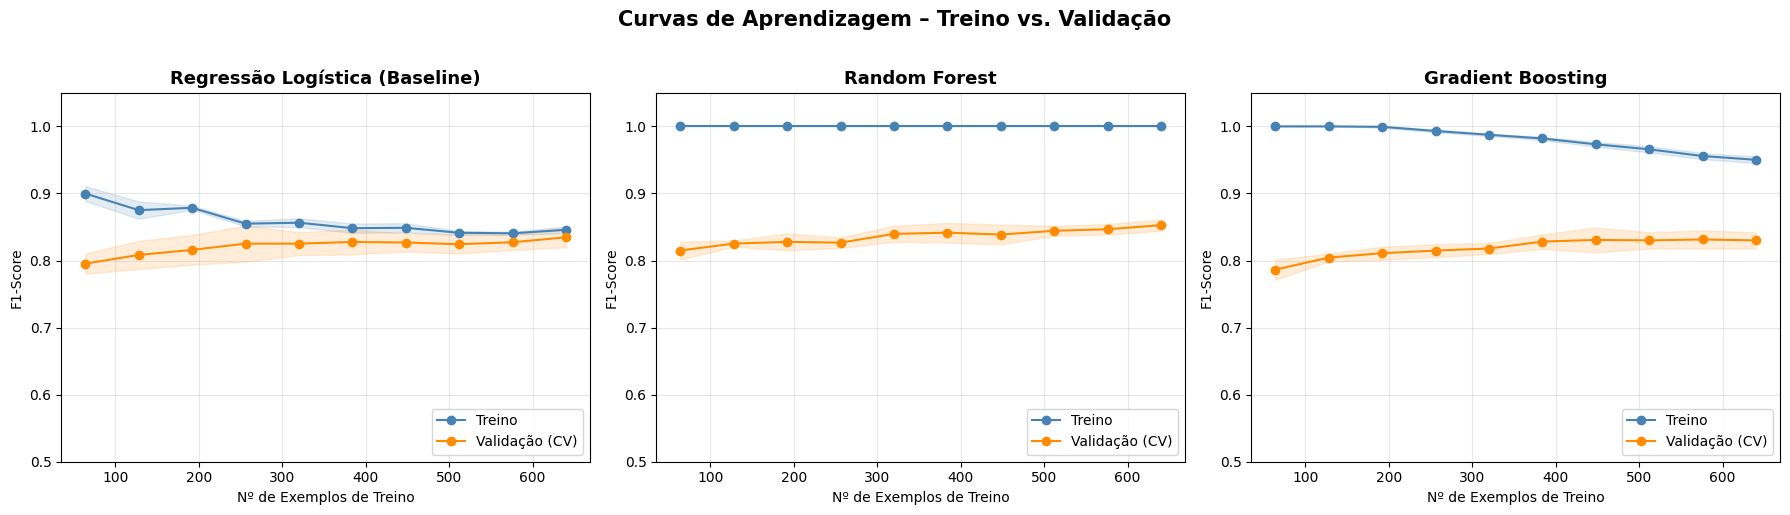

In [10]:
def plot_learning_curve(estimator, title, X, y, cv, scoring='f1', n_jobs=-1):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        cv=cv, scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=n_jobs
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.plot(train_sizes, train_mean, 'o-', color='steelblue',  label='Treino')
    plt.plot(train_sizes, val_mean,   'o-', color='darkorange', label='Validação (CV)')
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='steelblue')
    plt.fill_between(train_sizes, val_mean-val_std,   val_mean+val_std,   alpha=0.15, color='darkorange')
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel('Nº de Exemplos de Treino')
    plt.ylabel('F1-Score')
    plt.ylim(0.5, 1.05)
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)

modelos_curvas = {
    'Regressão Logística (Baseline)': baseline,
    'Random Forest': candidatos['Random Forest'],
    'Gradient Boosting': candidatos['Gradient Boosting']
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nome, modelo) in zip(axes, modelos_curvas.items()):
    plt.sca(ax)
    plot_learning_curve(modelo, nome, X_train, y_train, cv=cv)

plt.suptitle('Curvas de Aprendizagem – Treino vs. Validação', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Otimização (Tuning) – Gradient Boosting
(Rita Vinagreiro)

Com base nos resultados anteriores, o **Gradient Boosting** apresentou o melhor equilíbrio entre F1 e AUC-ROC. Aplicamos `GridSearchCV` com `StratifiedKFold (K=5)` para encontrar os hiperparâmetros ótimos, evitando overfitting.

In [11]:
param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.05, 0.10, 0.15],
    'subsample':     [0.8, 1.0]
}

gb_base = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'\nMelhores hiperparâmetros encontrados:')
print(grid_search.best_params_)
print(f'\nMelhor F1-Score (CV): {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Melhores hiperparâmetros encontrados:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Melhor F1-Score (CV): 0.8415


In [12]:
# Avaliação do modelo otimizado
modelo_final = grid_search.best_estimator_

y_pred_final = modelo_final.predict(X_test)
y_prob_final = modelo_final.predict_proba(X_test)[:, 1]

f1_final  = f1_score(y_test, y_pred_final)
auc_final = roc_auc_score(y_test, y_prob_final)

print('=== MODELO FINAL OTIMIZADO – Gradient Boosting ===')
print(f'F1-Score  (Teste):   {f1_final:.4f}   |   Baseline: {f1_baseline:.4f}   |   Melhoria: +{f1_final - f1_baseline:.4f}')
print(f'AUC-ROC   (Teste):   {auc_final:.4f}   |   Baseline: {auc_baseline:.4f}   |   Melhoria: +{auc_final - auc_baseline:.4f}')
print()
print(classification_report(y_test, y_pred_final, target_names=['Mau Crédito (0)', 'Bom Crédito (1)']))

=== MODELO FINAL OTIMIZADO – Gradient Boosting ===
F1-Score  (Teste):   0.8647   |   Baseline: 0.8609   |   Melhoria: +0.0038
AUC-ROC   (Teste):   0.8144   |   Baseline: 0.8700   |   Melhoria: +-0.0556

                 precision    recall  f1-score   support

Mau Crédito (0)       0.76      0.47      0.58        60
Bom Crédito (1)       0.80      0.94      0.86       140

       accuracy                           0.80       200
      macro avg       0.78      0.70      0.72       200
   weighted avg       0.79      0.80      0.78       200



# Avaliação do Modelo Final
(Rita Vinagreiro)

### Matriz de Confusão

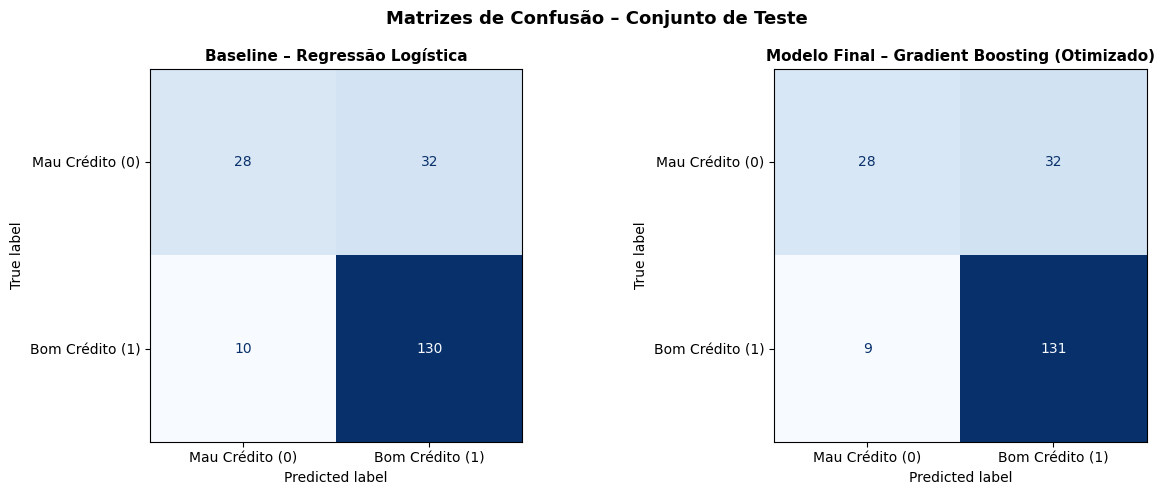

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (y_pred, titulo) in zip(axes, [
    (y_pred_baseline, 'Baseline – Regressão Logística'),
    (y_pred_final,    'Modelo Final – Gradient Boosting (Otimizado)')
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Mau Crédito (0)', 'Bom Crédito (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo, fontsize=11, fontweight='bold')

plt.suptitle('Matrizes de Confusão – Conjunto de Teste', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Análise detalhada de erros
cm_final = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm_final.ravel()

print('=== ANÁLISE DE ERROS DO MODELO FINAL ===')
print(f'Verdadeiros Negativos  (TN): {tn}  → Mau crédito corretamente identificado')
print(f'Falsos Positivos       (FP): {fp}  → Mau crédito aprovado incorretamente  ⚠')
print(f'Falsos Negativos       (FN): {fn}  → Bom crédito recusado incorretamente')
print(f'Verdadeiros Positivos  (TP): {tp}  → Bom crédito corretamente aprovado')
print(f'\nTaxa de Falsos Positivos: {fp/(fp+tn)*100:.1f}% (risco financeiro para o banco)')
print(f'Taxa de Falsos Negativos: {fn/(fn+tp)*100:.1f}% (oportunidade de negócio perdida)')

=== ANÁLISE DE ERROS DO MODELO FINAL ===
Verdadeiros Negativos  (TN): 28  → Mau crédito corretamente identificado
Falsos Positivos       (FP): 32  → Mau crédito aprovado incorretamente  ⚠
Falsos Negativos       (FN): 9  → Bom crédito recusado incorretamente
Verdadeiros Positivos  (TP): 131  → Bom crédito corretamente aprovado

Taxa de Falsos Positivos: 53.3% (risco financeiro para o banco)
Taxa de Falsos Negativos: 6.4% (oportunidade de negócio perdida)


### Curva ROC 

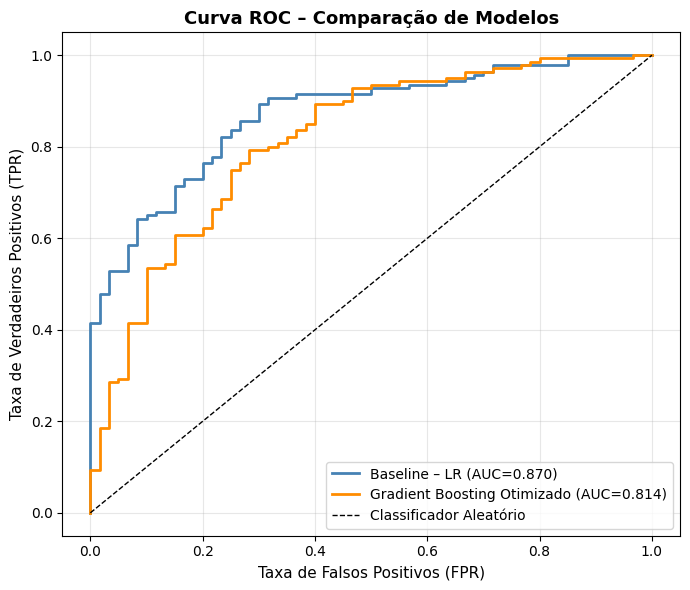

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))

for y_prob, nome, cor in [
    (y_prob_baseline, f'Baseline – LR (AUC={auc_baseline:.3f})', 'steelblue'),
    (y_prob_final,    f'Gradient Boosting Otimizado (AUC={auc_final:.3f})', 'darkorange')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, label=nome, color=cor)

ax.plot([0,1],[0,1], 'k--', lw=1, label='Classificador Aleatório')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=11)
ax.set_title('Curva ROC – Comparação de Modelos', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Importância dos Atributos

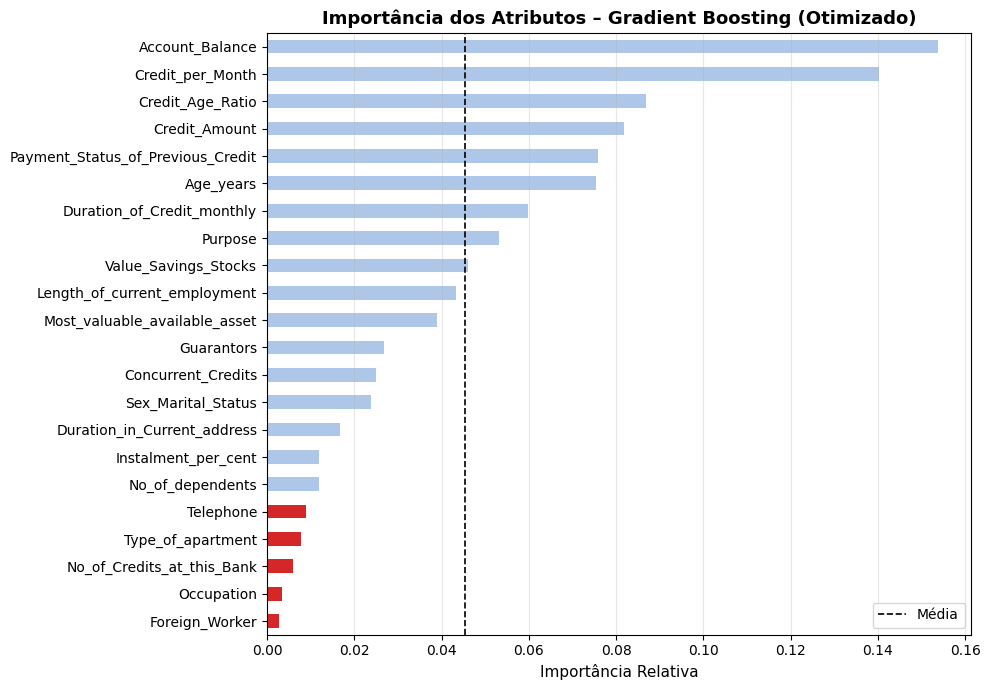


Top 5 variáveis mais importantes:
  1. Account_Balance: 0.1538
  2. Credit_per_Month: 0.1402
  3. Credit_Age_Ratio: 0.0870
  4. Credit_Amount: 0.0817
  5. Payment_Status_of_Previous_Credit: 0.0758


In [16]:
importancias = pd.Series(
    modelo_final.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
cores = ['#d62728' if i < 5 else '#aec7e8' for i in range(len(importancias))]
importancias.plot(kind='barh', ax=ax, color=cores[::-1])
ax.invert_yaxis()
ax.set_title('Importância dos Atributos – Gradient Boosting (Otimizado)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importância Relativa', fontsize=11)
ax.axvline(importancias.mean(), color='black', linestyle='--', lw=1.2, label='Média')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 variáveis mais importantes:')
for i, (var, imp) in enumerate(importancias.head(5).items(), 1):
    print(f'  {i}. {var}: {imp:.4f}')

# Conclusão
(Ana Silva)

In [17]:
print('=' * 60)
print('       RESUMO FINAL – MILESTONE 3')
print('=' * 60)
print(f'  Modelo Selecionado:  Gradient Boosting (GridSearchCV)')
print(f'  Melhores Parâmetros: {grid_search.best_params_}')
print(f'  F1-Score  (Teste):  {f1_final:.4f}  (meta: ≥ 0.80)')
print(f'  AUC-ROC   (Teste):  {auc_final:.4f}  (meta: ≥ 0.80)')
print()
print(f'  Meta F1-Score atingida:  {"✔ SIM" if f1_final >= 0.80 else "✘ NÃO"}')
print(f'  Meta AUC-ROC  atingida:  {"✔ SIM" if auc_final >= 0.80 else "✘ NÃO"}')
print('=' * 60)

       RESUMO FINAL – MILESTONE 3
  Modelo Selecionado:  Gradient Boosting (GridSearchCV)
  Melhores Parâmetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
  F1-Score  (Teste):  0.8647  (meta: ≥ 0.80)
  AUC-ROC   (Teste):  0.8144  (meta: ≥ 0.80)

  Meta F1-Score atingida:  ✔ SIM
  Meta AUC-ROC  atingida:  ✔ SIM
